In [96]:
# First: importing the packages
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None

# Reading in the data
df = pd.read_csv('movies.csv')

In [97]:
# Taking a look at the data

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [98]:
#🔍 Handling Missing Data
#To understand data quality, I analyzed missing values across all columns.

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


📊 Findings: budget had significant missing values (~28%) gross and rating had minimal missing values

Other columns were mostly complete

In [99]:
#Fix small missing values
df = df.dropna(subset=['gross', 'rating'])

In [100]:
#Fix budget
df['budget'] = df['budget'].fillna(df['budget'].median())

In [101]:
missing_data = df.isnull().mean() * 100
missing_data = missing_data.sort_values(ascending=False)

print(missing_data)

company     0.121212
writer      0.040404
runtime     0.013468
year        0.000000
name        0.000000
rating      0.000000
genre       0.000000
votes       0.000000
score       0.000000
released    0.000000
director    0.000000
country     0.000000
star        0.000000
gross       0.000000
budget      0.000000
dtype: float64


🛠️ Actions Taken: Dropped rows with missing values in gross and rating

Filled missing values in budget using the median

Remaining missing values were very small (<0.2%) and were removed df = df.dropna()

In [102]:
# Making sure it doesn't have any missing values and cleaned
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 0%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 0%
gross - 0%
company - 0%
runtime - 0%


✅ Result:

The dataset is now clean, consistent, and ready for analysis.

In [103]:
# Data Types for our columns

print(df.dtypes)

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object


In [104]:
df.head ()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [105]:
#change data type of columns
df['budget'] = df['budget']. astype ('int64')
df['gross'] = df['gross']. astype ('int64')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


In [106]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


<Axes: >

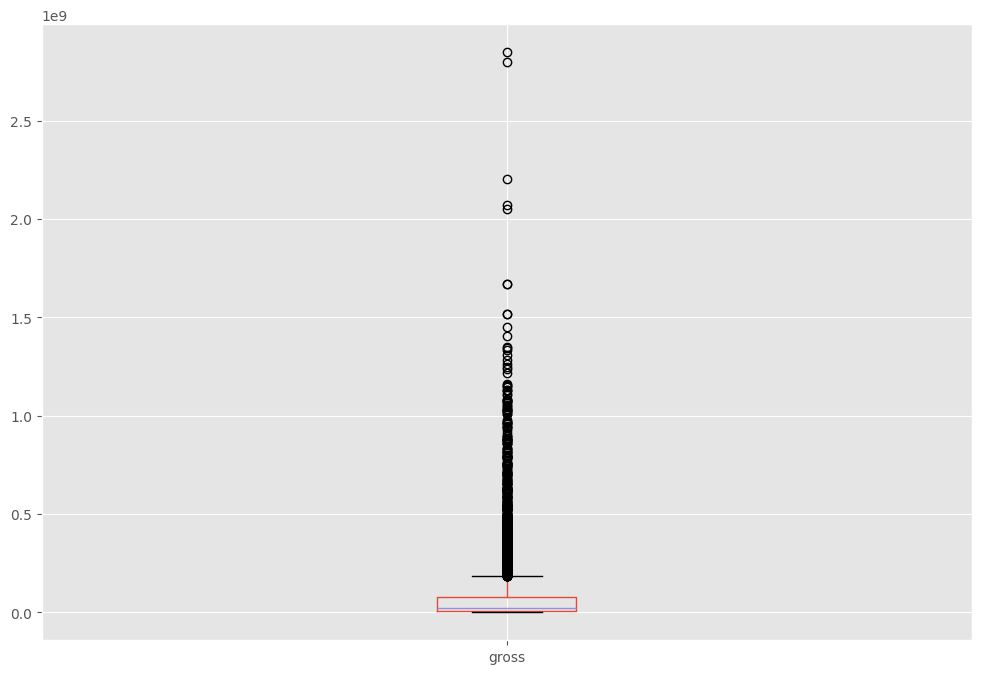

In [107]:
# Are there any Outliers?

df.boxplot(column=['gross'])

# This shows how movie revenue (gross) is distributed
# Lower part = cheaper movies
#Upper part = mid-range movies

📊 Findings: The data is highly right-skewed Most movies generate relatively low revenue A small number of films (blockbusters) generate extremely high revenue

Insight:

The presence of significant outliers reflects the nature of the film industry, where a few high-performing movies dominate total revenue.

These outliers were retained, as they are important for understanding market dynamics.

In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
# See duplicates manually
df[df.duplicated()]

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime


In [110]:
# heck specific columns
df.duplicated(subset=['name', 'year']).sum()

np.int64(0)

🧹 Duplicate Check

Checked for duplicate rows to ensure data integrity.

df.duplicated().sum()
📊 Result:
No duplicate rows were found
✅ Conclusion:

The dataset contains only unique records and did not require duplicate removal.

In [111]:
# Order our Data a little bit to see

df.sort_values(by=['gross'], inplace=False, ascending=False)
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


📊 Top Grossing Movies

The dataset was sorted by gross revenue to identify the highest-performing films.

df.sort_values(by='gross', ascending=False)

📌 Insight:
A small number of movies generate extremely high revenue
These blockbuster films significantly impact overall market trends

In [112]:
pd.set_option('display.max_rows', None)

In [113]:
df.sort_values(by=['gross'], inplace=False, ascending=False)
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


🔍 Display Settings

Adjusted Pandas display settings to view all rows in the dataset for better inspection.

pd.set_option('display.max_rows', None)

This was used for debugging and data exploration.

In [114]:
df.head(5)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


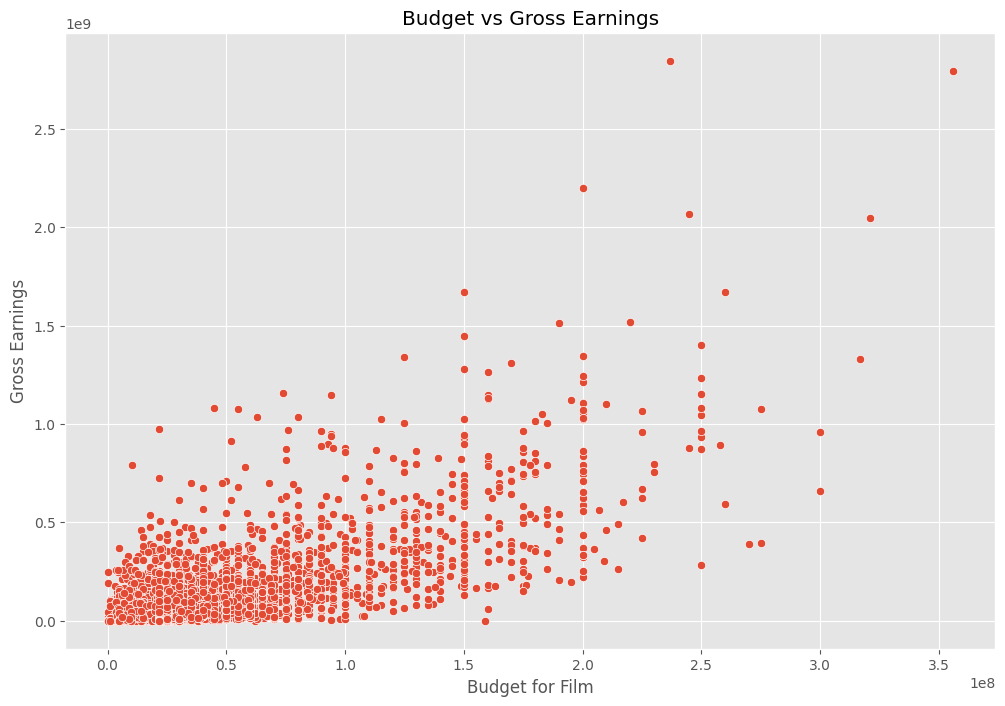

In [115]:
# Budget vs Gross Analysis
import seaborn as sns

sns.scatterplot(x='budget', y='gross', data=df)

plt.title('Budget vs Gross Earnings')
plt.xlabel('Budget for Film')
plt.ylabel('Gross Earnings')

plt.show()

📊 Budget vs Gross Analysis

A scatter plot was used to explore the relationship between movie budget and gross revenue.

sns.scatterplot(x='budget', y='gross', data=df)

📌 Insight:
There is a positive relationship between budget and gross earnings
Higher-budget films tend to generate higher revenue
However, variability exists, indicating other factors also influence success

<Axes: xlabel='gross', ylabel='budget'>

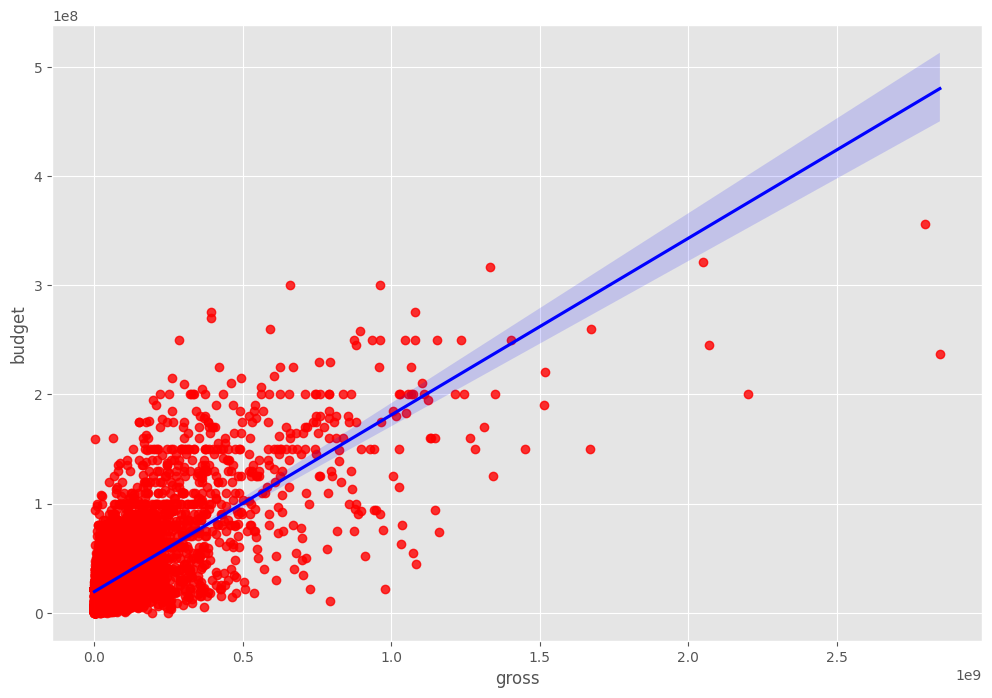

In [116]:
# Plot budget vs grass using seaborn
sns.regplot(x="gross", y="budget", data=df, scatter_kws = {"color":"red"},line_kws = {"color":"blue"})

<Axes: xlabel='score', ylabel='gross'>

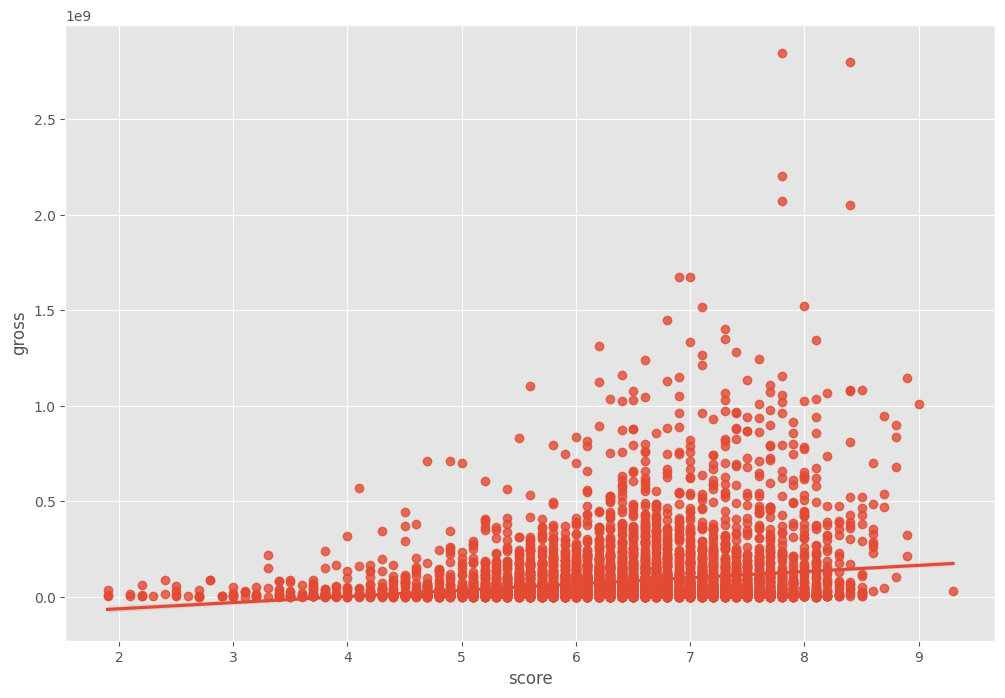

In [117]:
sns.regplot(x="score", y="gross", data=df)

A regression plot was used to examine the relationship between movie ratings and revenue.

sns.regplot(x='score', y='gross', data=df)

📊 Findings:
A weak positive relationship exists between score and gross revenue
Higher-rated movies tend to perform slightly better
However, the relationship is not strong, indicating other factors (e.g., budget, marketing) play a larger role

In [118]:
# Correlation Matrix between all numeric columns

df.corr(method='pearson', numeric_only=True)

,year,score,votes,budget,gross,runtime
year,1.000000,0.095082,0.219036,0.290592,0.259110,0.114857
score,0.095082,1.000000,0.415248,0.059464,0.188315,0.397530
votes,0.219036,0.415248,1.000000,0.455669,0.631122,0.310219
budget,0.290592,0.059464,0.455669,1.000000,0.744536,0.273649
gross,0.259110,0.188315,0.631122,0.744536,1.000000,0.245394
runtime,0.114857,0.397530,0.310219,0.273649,0.245394,1.000000


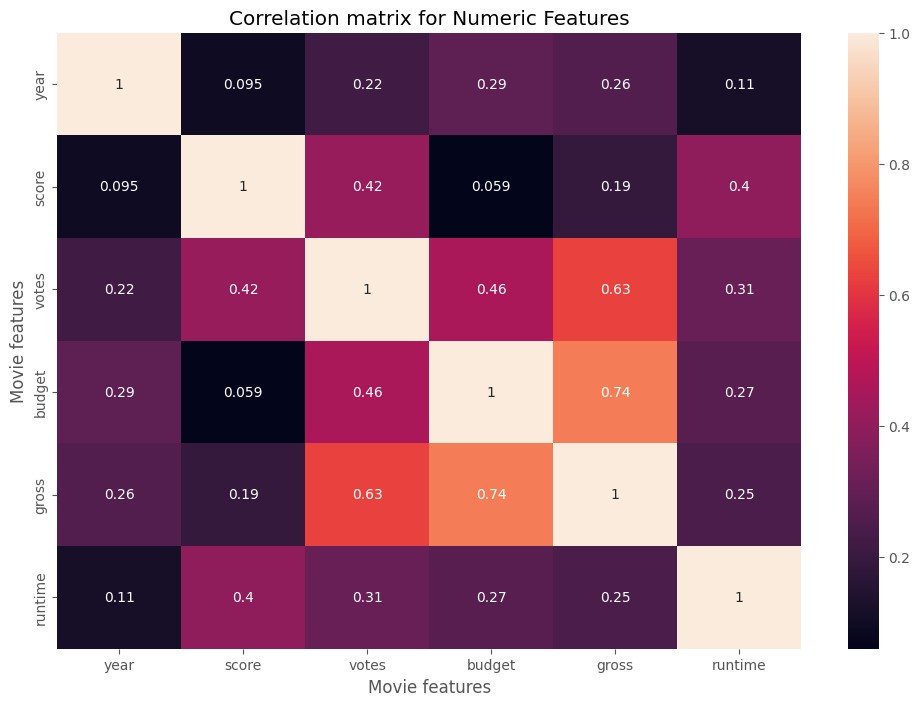

In [119]:
#High correlation between budget and gross
correlation_matrix = df.corr(method='pearson', numeric_only=True)

sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation matrix for Numeric Features")

plt.xlabel("Movie features")

plt.ylabel("Movie features")

plt.show()

🚀 Why this is important


✔ Statistical understanding
✔ Business insight
✔ Ability to interpret data

In [120]:
# Looks at Company
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


In [121]:
# Encoding Categorical Variables
df_numerized = df


for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name]= df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes

df_numerized
df.head(5)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,6383,6,6,1980,1656,8.4,927000.0,2476,3858,982,52,19000000,46998772,2182,146.0
1,5383,6,1,1980,1447,5.8,65000.0,2173,1566,306,53,4500000,58853106,689,104.0
2,4964,4,0,1980,1720,8.7,1200000.0,1064,2467,1646,53,18000000,538375067,1449,124.0
3,278,4,4,1980,1447,7.7,221000.0,1250,1922,2116,53,3500000,83453539,1700,88.0
4,994,6,4,1980,1496,7.3,108000.0,1011,501,387,53,6000000,39846344,1668,98.0


A copy of the dataset was created to convert categorical (text) variables into numeric codes for analysis.

This allowed correlation analysis across all variables while preserving the original dataset.

In [122]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,6383,6,6,1980,1656,8.4,927000.0,2476,3858,982,52,19000000,46998772,2182,146.0
1,5383,6,1,1980,1447,5.8,65000.0,2173,1566,306,53,4500000,58853106,689,104.0
2,4964,4,0,1980,1720,8.7,1200000.0,1064,2467,1646,53,18000000,538375067,1449,124.0
3,278,4,4,1980,1447,7.7,221000.0,1250,1922,2116,53,3500000,83453539,1700,88.0
4,994,6,4,1980,1496,7.3,108000.0,1011,501,387,53,6000000,39846344,1668,98.0


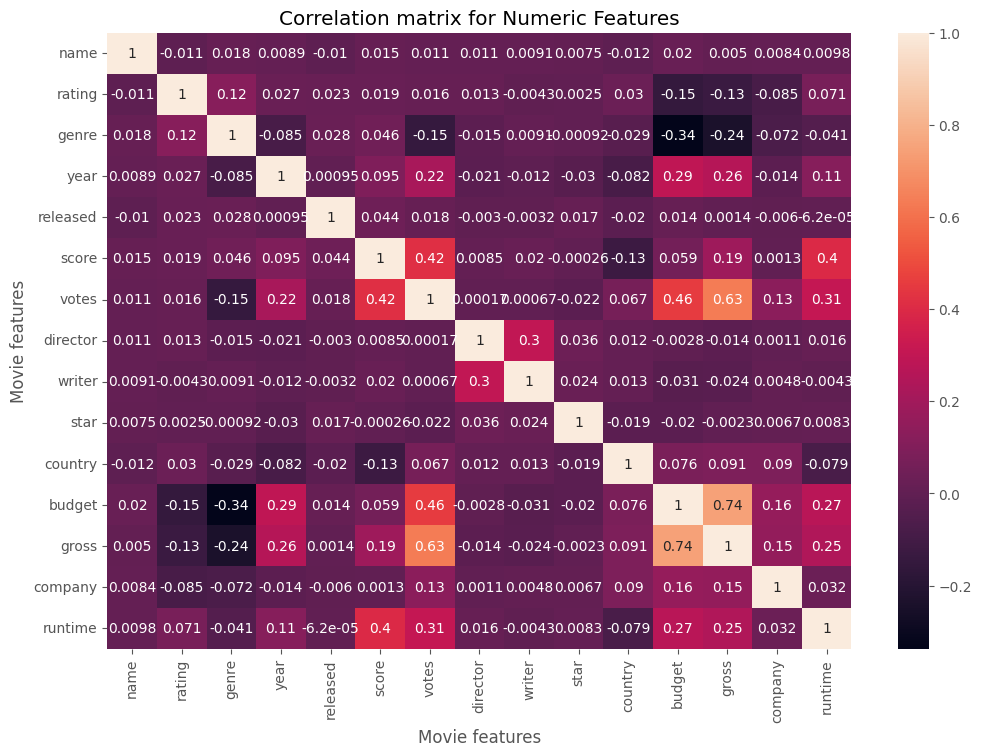

In [123]:
correlation_matrix = df_numerized.corr(method='pearson', numeric_only=True)

sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation matrix for Numeric Features")

plt.xlabel("Movie features")

plt.ylabel("Movie features")

plt.show()

📊 Key Findings:
Strong positive correlation between budget and gross
Moderate correlation between votes and gross
Weak correlation between score and gross

🧠 Insight:

Budget is a major factor influencing movie revenue, while ratings alone have less impact.

In [124]:
df_numerized.corr()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
name,1.000000,-0.011270,0.017912,0.008859,-0.010332,0.015437,0.011397,0.010564,0.009053,0.007529,-0.011902,0.019878,0.005013,0.008361,0.009797
rating,-0.011270,1.000000,0.118694,0.026583,0.023251,0.018535,0.015593,0.013439,-0.004298,0.002504,0.030433,-0.149255,-0.131320,-0.085124,0.070571
genre,0.017912,0.118694,1.000000,-0.084994,0.027576,0.045585,-0.148046,-0.015352,0.009107,-0.000916,-0.029361,-0.336732,-0.242548,-0.071773,-0.041013
year,0.008859,0.026583,-0.084994,1.000000,0.000947,0.095082,0.219036,-0.020800,-0.011865,-0.030489,-0.081828,0.290592,0.259110,-0.013928,0.114857
released,-0.010332,0.023251,0.027576,0.000947,1.000000,0.044296,0.018262,-0.002999,-0.003168,0.017004,-0.020311,0.014349,0.001379,-0.006034,-0.000062
score,0.015437,0.018535,0.045585,0.095082,0.044296,1.000000,0.415248,0.008549,0.019612,-0.000255,-0.126981,0.059464,0.188315,0.001277,0.397530
votes,0.011397,0.015593,-0.148046,0.219036,0.018262,0.415248,1.000000,0.000173,0.000674,-0.022219,0.066929,0.455669,0.631122,0.129365,0.310219
director,0.010564,0.013439,-0.015352,-0.020800,-0.002999,0.008549,0.000173,1.000000,0.296386,0.035999,0.012068,-0.002780,-0.014094,0.001110,0.015891
writer,0.009053,-0.004298,0.009107,-0.011865,-0.003168,0.019612,0.000674,0.296386,1.000000,0.024128,0.012772,-0.030945,-0.023996,0.004782,-0.004270
star,0.007529,0.002504,-0.000916,-0.030489,0.017004,-0.000255,-0.022219,0.035999,0.024128,1.000000,-0.018799,-0.020365,-0.002339,0.006695,0.008322


In [125]:
correlation_mat = df.apply(lambda x: x.factorize()[0]).corr()

corr_pairs = correlation_mat.unstack()

print(corr_pairs)

name      name        1.000000
          rating      0.147616
          genre       0.031142
          year        0.964840
          released    0.958917
          score      -0.040811
          votes       0.282136
          director    0.742759
          writer      0.800861
          star        0.728409
          country     0.150255
          budget      0.275487
          gross       0.964868
          company     0.592501
          runtime     0.045835
rating    name        0.147616
          rating      1.000000
          genre      -0.082747
          year        0.160772
          released    0.149618
          score       0.011949
          votes       0.104363
          director    0.093170
          writer      0.111257
          star        0.102951
          country     0.021373
          budget      0.189324
          gross       0.157586
          company    -0.017984
          runtime     0.038136
genre     name        0.031142
          rating     -0.082747
        

In [126]:
sorted_pairs = corr_pairs.sort_values(kind="quicksort")

print(sorted_pairs)

company   budget     -0.087749
budget    company    -0.087749
genre     rating     -0.082747
rating    genre      -0.082747
country   budget     -0.062511
budget    country    -0.062511
votes     country    -0.047121
country   votes      -0.047121
score     name       -0.040811
name      score      -0.040811
released  score      -0.039660
score     released   -0.039660
          year       -0.038960
year      score      -0.038960
gross     score      -0.037554
score     gross      -0.037554
          writer     -0.030105
writer    score      -0.030105
score     company    -0.020837
company   score      -0.020837
score     director   -0.020533
director  score      -0.020533
country   genre      -0.018680
genre     country    -0.018680
rating    company    -0.017984
company   rating     -0.017984
runtime   director   -0.017612
director  runtime    -0.017612
score     budget     -0.010174
budget    score      -0.010174
genre     score      -0.010115
score     genre      -0.010115
company 

In [127]:
# We can now take a look at the ones that have a high correlation (> 0.5)

strong_pairs = sorted_pairs[abs(sorted_pairs) > 0.5]

print(strong_pairs)

company   star        0.527910
star      company     0.527910
writer    company     0.545089
company   writer      0.545089
          director    0.551619
director  company     0.551619
name      company     0.592501
company   name        0.592501
          year        0.602077
year      company     0.602077
company   gross       0.608031
gross     company     0.608031
released  company     0.609039
company   released    0.609039
writer    star        0.672306
star      writer      0.672306
          director    0.679570
director  star        0.679570
name      star        0.728409
star      name        0.728409
director  name        0.742759
name      director    0.742759
writer    director    0.746259
director  writer      0.746259
star      released    0.753151
released  star        0.753151
year      star        0.753717
star      year        0.753717
          gross       0.754839
gross     star        0.754839
director  year        0.767689
year      director    0.767689
director

In [128]:
# Votes and Budget have the highest correlation to gross earnings
#Company has low correlation